# P01 — Linear Algebra by hand  *(the mind's first sense)*

> **The story so far.** In [P00](P00_Python_and_NumPy_for_ML.ipynb) our newborn mind opened its
> eyes and saw the world as **numbers** — and we taught it to hold and move them in bulk with NumPy.
> But a pile of numbers isn't a thought. A thought needs *relating* one thing to another. So today
> the mind grows its very first **sense** — a way to feel, in a single number, *how much two things
> agree*. That sense is the **dot product**, and astonishingly, almost everything a neural network
> ever does is built from it: a layer is a stack of dot products, attention is dot products, search
> is dot products. Give the mind this one sense and the rest of deep learning is plumbing.

Everything a neural network computes is built from a tiny set of linear-algebra operations on
vectors and matrices. If you own these, the rest of deep learning is plumbing. We build them up
in order — **dot product → matrix×vector → matrix×matrix → transpose → norms → cosine similarity**
— each one *plain words → tiny worked example by hand → code that verifies the same numbers*.

We use NumPy (from [P00](P00_Python_and_NumPy_for_ML.ipynb)). The single most important operator
here is `@`, which means **matrix multiply** (not element-wise `*`). Keep that distinction sharp.

## B1 — The dot product: two vectors in, one number out

Picture a music app sizing you up. It keeps a little list of numbers for you — *how much you like
loud, fast, sad, acoustic…* — and an identical list for every song. To guess whether you'll love a
track it lines the two lists up, multiplies them term by term, and adds the results into **one
number**: high if your tastes and the song point the same way, low if they clash. That single move
— *how much do these two things agree?* — is the dot product, the mind's first sense.

**What it does:** multiply two equal-length vectors position-by-position, then add it all up. The
result is a single number that measures **how aligned** the two vectors are.

**Formula (length 3):**  `a · b = a0*b0 + a1*b1 + a2*b2`

**Worked example by hand.** `a = [2, 1, 3]`, `b = [1, 0, 2]`:
```
a · b = (2×1) + (1×0) + (3×2) = 2 + 0 + 6 = 8
```

**Why we care:** the dot product is the atom of *every* layer and of attention. Big positive →
the vectors point the same way (similar); zero → perpendicular (unrelated); negative → opposite.

In [1]:
import numpy as np
a = np.array([2.0, 1.0, 3.0])
b = np.array([1.0, 0.0, 2.0])

print("elementwise a*b :", a * b, " (multiply position by position)")
print("sum of those    :", (a * b).sum(), " <- the dot product, hand = 8")
print("np.dot(a, b)    :", np.dot(a, b))
print("a @ b           :", a @ b, " (the @ operator IS the dot product for 1-D)")

print("\nalignment intuition:")
print(" [1,0]·[1,0]  =", np.array([1,0]) @ np.array([1,0]), " same direction -> big")
print(" [1,0]·[0,1]  =", np.array([1,0]) @ np.array([0,1]), " perpendicular  -> 0")
print(" [1,0]·[-1,0] =", np.array([1,0]) @ np.array([-1,0])," opposite       -> negative")

elementwise a*b : [2. 0. 6.]  (multiply position by position)
sum of those    : 8.0  <- the dot product, hand = 8
np.dot(a, b)    : 8.0
a @ b           : 8.0  (the @ operator IS the dot product for 1-D)

alignment intuition:
 [1,0]·[1,0]  = 1  same direction -> big
 [1,0]·[0,1]  = 0  perpendicular  -> 0
 [1,0]·[-1,0] = -1  opposite       -> negative


### 📊 Step 4 — See it & play with it: the dot product is really about *direction*

Numbers verified — now *see why*. The picture draws `a` (red) and `b` (blue) as arrows from the
origin. Geometrically the dot product is `a·b = |a|·|b|·cos(θ)`, where `θ` is the angle between them.
So it is **biggest when they point the same way (θ=0°), exactly zero when perpendicular (θ=90°), and
negative when they oppose (θ>90°)**. The dashed green arrow is `b`'s *projection* onto `a` — the dot
product is `|a|` times that projection's length.

**▶ Run the cell, then drag the sliders** to move the arrows. Goals to build intuition:
1. Make `a·b` exactly **0** (the arrows should look perpendicular).
2. Make `a·b` as **negative** as you can (point them opposite ways).
3. Keep the angle fixed but lengthen `b` — watch the dot product grow even though the *direction* didn't change (this is the flaw cosine similarity fixes in B6).

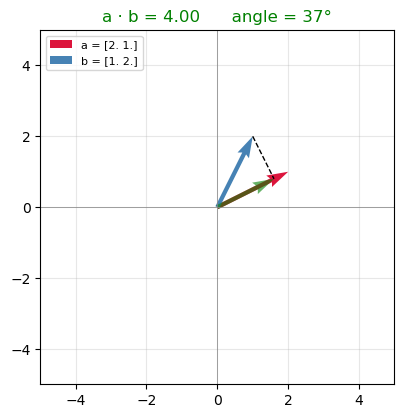

interactive(children=(FloatSlider(value=1.0, description='b.x', max=4.0, min=-4.0, step=0.5), FloatSlider(valu…

In [2]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_dot(bx=1.0, by=2.0, ax=2.0, ay=1.0):
    a = np.array([ax, ay]); b = np.array([bx, by])
    dot = float(a @ b)
    cosang = dot / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-9)
    angle = np.degrees(np.arccos(np.clip(cosang, -1, 1)))
    fig, axp = plt.subplots(figsize=(4.6, 4.6))
    axp.axhline(0, color="gray", lw=.5); axp.axvline(0, color="gray", lw=.5)
    axp.quiver(0,0,*a, angles="xy", scale_units="xy", scale=1, color="crimson",  width=.012, label=f"a = {a}")
    axp.quiver(0,0,*b, angles="xy", scale_units="xy", scale=1, color="steelblue", width=.012, label=f"b = {b}")
    proj = (a @ b)/(a @ a + 1e-9) * a                       # projection of b onto a
    axp.quiver(0,0,*proj, angles="xy", scale_units="xy", scale=1, color="green", alpha=.6, width=.012)
    axp.plot([b[0],proj[0]],[b[1],proj[1]], "k--", lw=1)
    lim=5; axp.set_xlim(-lim,lim); axp.set_ylim(-lim,lim); axp.set_aspect("equal"); axp.grid(alpha=.3)
    tcolor = "green" if dot > 1e-9 else ("gray" if abs(dot) <= 1e-9 else "red")
    axp.set_title(f"a · b = {dot:.2f}      angle = {angle:.0f}°", color=tcolor, fontsize=12)
    axp.legend(loc="upper left", fontsize=8)
    plt.show()

show_dot()                                                  # static picture (always visible)
interact(show_dot,                                          # ▶ live sliders (drag them in your IDE)
         bx=FloatSlider(min=-4, max=4, step=0.5, value=1.0, description="b.x"),
         by=FloatSlider(min=-4, max=4, step=0.5, value=2.0, description="b.y"),
         ax=FloatSlider(min=-4, max=4, step=0.5, value=2.0, description="a.x"),
         ay=FloatSlider(min=-4, max=4, step=0.5, value=1.0, description="a.y"));

## B2 — Matrix × vector = one dot product per row = a neural-network layer

One sense is good; a *panel* of senses is better. Imagine a job application scored by three judges
at once — one weighs your experience, one your skills, one your interview — each judge holding their
own little list of weights and each producing one number from the same applicant. Stack the judges'
weight-lists as the **rows of a matrix**, feed in the applicant as a vector, and a single
matrix×vector gives you all three verdicts in one stroke. That is *literally* what a neural-network
layer is: a panel of dot products firing together.

A matrix-times-vector is just **the dot product of each row of the matrix with the vector**. The
output has one number per row.

**Worked example by hand.**
```
W = [ 1  2 ]        x = [ 2 ]
    [ 0  1 ]            [ 1 ]
    [ 3  1 ]
row 0: [1,2]·[2,1] = 1·2 + 2·1 = 4
row 1: [0,1]·[2,1] = 0·2 + 1·1 = 1
row 2: [3,1]·[2,1] = 3·2 + 1·1 = 7        ->  W x = [4, 1, 7]
```

**Shape rule:** `(rows × inner) @ (inner,) → (rows,)`. The inner sizes must match and "cancel":
`(3×2) @ (2,) → (3,)`. This single operation took a 2-number input to a 3-number output — that is
*exactly* what a `Linear` layer does. The numbers inside `W` are what training learns.

In [3]:
import numpy as np
W = np.array([[1.0, 2.0],
              [0.0, 1.0],
              [3.0, 1.0]])      # (3, 2)
x = np.array([2.0, 1.0])        # (2,)

print("W shape", W.shape, " x shape", x.shape)
print("W @ x =", W @ x, " (hand [4 1 7])")
print("shape of result:", (W @ x).shape, " -> (3,), one number per row\n")
for i in range(W.shape[0]):
    print(f"  row {i}: {W[i]} · {x} = {W[i] @ x}")

W shape (3, 2)  x shape (2,)
W @ x = [4. 1. 7.]  (hand [4 1 7])
shape of result: (3,)  -> (3,), one number per row

  row 0: [1. 2.] · [2. 1.] = 4.0
  row 1: [0. 1.] · [2. 1.] = 1.0
  row 2: [3. 1.] · [2. 1.] = 7.0


### 📊 Step 4 — See it & play with it: a matrix *transforms* space

A matrix isn't just arithmetic — it **moves vectors to new positions**, and that is the whole reason
a neural-network layer can reshape data. To draw it we use a **2×2** `W` (so the input and output
both live in the plane; the 3×2 above is the same idea with an extra output dimension). The picture
shows the input `x` (red), where the matrix sends it `W·x` (blue), and how the grey **unit square**
is bent into the orange shape — *that deformation is the transformation `W` performs on all of space.*

**▶ Run the cell and drag the four entries of `W`:**
1. Set `W = [[1,0],[0,1]]` (the identity, B7) — `Wx` lands exactly on `x` and the square is unchanged.
2. Make the diagonal `[[2,0],[0,2]]` — everything doubles in size (pure scaling).
3. Add an off-diagonal like `W[0,1]=1` — the square **shears** into a parallelogram.
4. Try `[[0,-1],[1,0]]` — a 90° **rotation**. Matrices rotate, stretch, shear, and flip space.

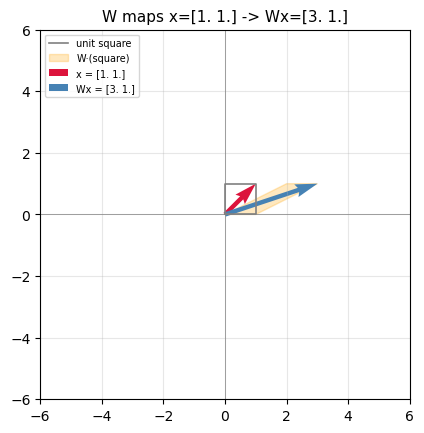

interactive(children=(FloatSlider(value=1.0, description='W[0,0]', max=3.0, min=-3.0, step=0.5), FloatSlider(v…

In [4]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_transform(w00=1.0, w01=2.0, w10=0.0, w11=1.0, xx=1.0, xy=1.0):
    W = np.array([[w00, w01], [w10, w11]]); x = np.array([xx, xy]); Wx = W @ x
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    ax.axhline(0, color="gray", lw=.5); ax.axvline(0, color="gray", lw=.5)
    square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T     # unit square corners
    img = W @ square                                          # where W sends the square
    ax.plot(square[0], square[1], color="gray", lw=1.2, label="unit square")
    ax.fill(img[0], img[1], color="orange", alpha=.25, label="W·(square)")
    ax.quiver(0,0,*x,  angles="xy", scale_units="xy", scale=1, color="crimson",  width=.012, label=f"x = {x}")
    ax.quiver(0,0,*Wx, angles="xy", scale_units="xy", scale=1, color="steelblue", width=.012, label=f"Wx = {np.round(Wx,2)}")
    lim=6; ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim); ax.set_aspect("equal"); ax.grid(alpha=.3)
    ax.set_title(f"W maps x={x} -> Wx={np.round(Wx,2)}", fontsize=11)
    ax.legend(loc="upper left", fontsize=7)
    plt.show()

show_transform()                                            # static picture (always visible)
interact(show_transform,                                    # ▶ live sliders (drag them in your IDE)
         w00=FloatSlider(min=-3,max=3,step=0.5,value=1.0,description="W[0,0]"),
         w01=FloatSlider(min=-3,max=3,step=0.5,value=2.0,description="W[0,1]"),
         w10=FloatSlider(min=-3,max=3,step=0.5,value=0.0,description="W[1,0]"),
         w11=FloatSlider(min=-3,max=3,step=0.5,value=1.0,description="W[1,1]"),
         xx=FloatSlider(min=-3,max=3,step=0.5,value=1.0,description="x[0]"),
         xy=FloatSlider(min=-3,max=3,step=0.5,value=1.0,description="x[1]"));

## B3 — Matrix × matrix: many dot products at once (a whole batch through a layer)

Now imagine the panel of judges interviewing a whole *room* of applicants — not one person, but
fifty, all at once. We don't want to re-run the judges fifty times; we want one sweeping operation
that scores everyone against every judge in a single pass. Stack the applicants as one matrix, the
judges as another, multiply, and out comes the full grid of verdicts. This is how a real model
pushes a **batch** of examples through a layer at once — the workhorse operation of all deep learning.

Real models push a **batch** of vectors through a layer in one shot. That's matrix×matrix: entry
`(i, j)` of the result is **row `i` of the left** dotted with **column `j` of the right**.

**Worked example by hand.**
```
A = [ 1  2 ]      B = [ 1  0  2 ]
    [ 3  4 ]          [ 0  1  1 ]
```
`A` is `(2,2)`, `B` is `(2,3)` → result is `(2,3)`. Compute each entry (row of A · column of B):
```
C[0,0]=[1,2]·[1,0]=1   C[0,1]=[1,2]·[0,1]=2   C[0,2]=[1,2]·[2,1]=4
C[1,0]=[3,4]·[1,0]=3   C[1,1]=[3,4]·[0,1]=4   C[1,2]=[3,4]·[2,1]=10
```
```
A @ B = [ 1  2  4 ]
        [ 3  4 10 ]
```
**Shape rule:** `(m×k) @ (k×n) → (m×n)`. The inner `k` must match. **Order matters:** `A@B ≠ B@A`
in general (here `B@A` isn't even a legal shape: `(2,3)@(2,2)` — inner 3≠2).

In [5]:
import numpy as np
A = np.array([[1, 2],
              [3, 4]])          # (2,2)
B = np.array([[1, 0, 2],
              [0, 1, 1]])       # (2,3)

print("A @ B =")
print(A @ B, "\n  hand [[1 2 4],[3 4 10]]   shape", (A @ B).shape)

# entry (1,2) by hand = row 1 of A dot column 2 of B
print("\nentry [1,2] = row1(A)·col2(B) =", A[1] @ B[:, 2], " (hand 10)")

# order matters / illegal shapes
print("\nis A@B == B-shape-compatible the other way?")
try:
    B @ A
except ValueError as e:
    print("  B @ A fails:", e, "(inner dims 3 vs 2)")

A @ B =
[[ 1  2  4]
 [ 3  4 10]] 
  hand [[1 2 4],[3 4 10]]   shape (2, 3)

entry [1,2] = row1(A)·col2(B) = 10  (hand 10)

is A@B == B-shape-compatible the other way?
  B @ A fails: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3) (inner dims 3 vs 2)


## B4 — Transpose: flipping rows and columns

Sometimes the mind needs to compare *everyone with everyone* — every student in a class against
every other, to see who sits near whom. To line each person's vector up against all the others, you
flip one set of rows on its side so they become columns, and the multiply produces the whole grid of
pairwise agreements. That sideways flip is the **transpose**, and it is the quiet move that makes
attention — the heart of a transformer — possible.

The **transpose** `M.T` turns rows into columns. An `(m×n)` matrix becomes `(n×m)`. You meet it
constantly — most famously in attention, where scores are `Q @ K.T`.

**Worked example by hand.**
```
M = [ 1  2  3 ]            M.T = [ 1  4 ]
    [ 4  5  6 ]                  [ 2  5 ]
                                 [ 3  6 ]
```
Entry `M[i,j]` moves to `M.T[j,i]`. Shape `(2,3) → (3,2)`.

**Why it shows up:** to dot every row of `Q` with every row of `K` (all query–key pairs at once),
we compute `Q @ K.T` — transposing `K` lines its vectors up as columns so the matmul produces the
full grid of pairwise dot products. That grid is the attention score matrix (Notebook 00, B9).

In [6]:
import numpy as np
M = np.array([[1, 2, 3],
              [4, 5, 6]])
print("M shape", M.shape, "\nM.T =\n", M.T, "\nM.T shape", M.T.shape, "(hand (3,2))")

# the attention pattern: all pairwise dot products of rows of X
X = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [1.0, 1.0]])      # 3 vectors, 2-D each
scores = X @ X.T                # (3,2)@(2,3) -> (3,3): every pair's dot product
print("\nX @ X.T (all pairwise dot products = attention scores):")
print(scores)
print("entry [2,2] = row2·row2 =", X[2] @ X[2], " (hand 2: [1,1]·[1,1])")

M shape (2, 3) 
M.T =
 [[1 4]
 [2 5]
 [3 6]] 
M.T shape (3, 2) (hand (3,2))

X @ X.T (all pairwise dot products = attention scores):
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]
entry [2,2] = row2·row2 = 2.0  (hand 2: [1,1]·[1,1])


## B5 — Vector length (the L2 norm)

A delivery drone that flew 3 blocks east and 4 blocks north didn't travel 7 blocks — it travelled
5, the straight-line distance, by Pythagoras. The mind needs that same notion of *size*: how big is
this gradient, how strong is this weight, how far apart are these two ideas. That length is the
**norm**, and it's the very thing that lets us strip raw magnitude out of the dot product next.

The **norm** `||v||` is the length of a vector — Pythagoras in n dimensions: square each
component, add, square-root.

**Formula:**  `||v|| = sqrt(v0² + v1² + … )`

**Worked example by hand.** `v = [3, 4]`:
```
||v|| = sqrt(3² + 4²) = sqrt(9 + 16) = sqrt(25) = 5
```
(The classic 3-4-5 triangle.) Norms let us measure the *size* of things — gradients, weights,
errors — and they're the denominator that turns a raw dot product into **cosine similarity** next.

In [7]:
import numpy as np
v = np.array([3.0, 4.0])
print("v·v          =", v @ v, " (= 25, sum of squares)")
print("sqrt(v·v)    =", np.sqrt(v @ v), " (hand 5)")
print("np.linalg.norm(v) =", np.linalg.norm(v), " (the built-in, same answer)")

v·v          = 25.0  (= 25, sum of squares)
sqrt(v·v)    = 5.0  (hand 5)
np.linalg.norm(v) = 5.0  (the built-in, same answer)


## B6 — Cosine similarity: the dot product, made scale-free

Here's a flaw in the mind's new sense. A long review and a short tweet can praise the same movie in
the same *direction*, yet the long one — simply because it has more words — racks up a bigger dot
product. The mind would wrongly think the rambling reviewer agrees with it *more*. The fix is to ask
about direction alone, ignoring length: divide out both magnitudes. That's **cosine similarity**,
and it's how search engines and recommenders compare things of wildly different sizes fairly.

The raw dot product grows if vectors are simply *longer*, which can be misleading. **Cosine
similarity** removes length by dividing by both norms, leaving a pure measure of *direction* in
`[-1, 1]`: `+1` same direction, `0` perpendicular, `-1` opposite.

**Formula:**  `cos(a, b) = (a · b) / (||a|| · ||b||)`

**Worked example by hand.** `a = [1, 0]`, `b = [1, 1]`:
```
a · b   = 1·1 + 0·1 = 1
||a||   = sqrt(1) = 1
||b||   = sqrt(1+1) = sqrt(2) ≈ 1.414
cos     = 1 / (1 × 1.414) = 0.707   (= the cosine of 45°, since b is 45° off a)
```

**Why we care:** this is *the* way models measure "how similar are these two word-vectors?" — used
to find related words in embeddings (P18), to rank documents in RAG (P25), and conceptually inside
attention. Direction, not magnitude, carries the meaning.

In [8]:
import numpy as np
def cosine(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

a = np.array([1.0, 0.0])
b = np.array([1.0, 1.0])
print("cos([1,0], [1,1]) =", round(cosine(a, b), 3), " (hand 0.707 = cos 45 deg)")
print("cos(a, a)         =", cosine(a, a),           " (a vector with itself -> 1)")
print("cos([1,0],[0,1])  =", cosine(np.array([1,0]), np.array([0,1])), " (perpendicular -> 0)")
print("cos([1,0],[-1,0]) =", cosine(np.array([1,0]), np.array([-1,0]))," (opposite -> -1)")

# scale-free: doubling b does NOT change the cosine (but DOES change the raw dot product)
print("\nraw dot a·b =", a @ b, " vs a·(2b) =", a @ (2*b), " (changed)")
print("cos a,b     =", round(cosine(a, b),3), " vs cos a,2b =", round(cosine(a, 2*b),3), " (unchanged)")

cos([1,0], [1,1]) = 0.707  (hand 0.707 = cos 45 deg)
cos(a, a)         = 1.0  (a vector with itself -> 1)
cos([1,0],[0,1])  = 0.0  (perpendicular -> 0)
cos([1,0],[-1,0]) = -1.0  (opposite -> -1)

raw dot a·b = 1.0  vs a·(2b) = 2.0  (changed)
cos a,b     = 0.707  vs cos a,2b = 0.707  (unchanged)


### 📊 Step 4 — See it & play with it: cosine = the angle, length removed

Cosine similarity is pure *direction*. The picture rotates `b` around the circle while keeping `a`
fixed, and plots `cos(a, b)` against the angle — it traces the cosine curve: **+1** when they align
(0°), **0** when perpendicular (90°), **−1** when opposite (180°). Crucially, the slider that
*lengthens* `b` leaves the cosine unchanged — proving cosine ignores magnitude, the very flaw it
fixes versus the raw dot product (B1).

**▶ Run the cell and drag the sliders:**
1. Rotate `b` to 90° — cosine hits 0; to 180° — cosine hits −1.
2. Crank up `b length` — the blue arrow grows but **cosine doesn't move** (compare with B1, where the dot product *did*).

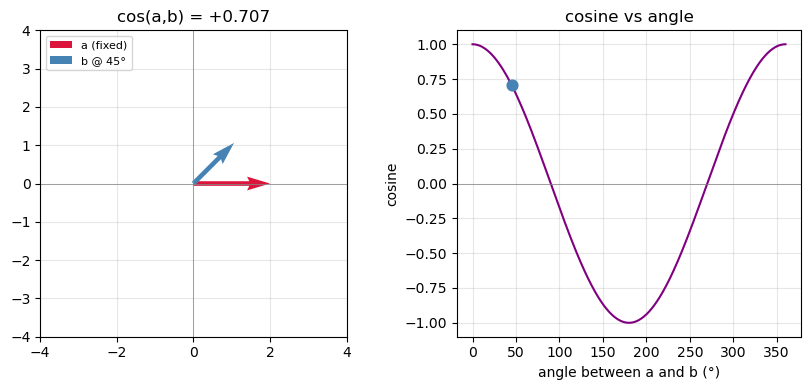

interactive(children=(FloatSlider(value=45.0, description='b angle°', max=360.0, step=15.0), FloatSlider(value…

In [9]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_cosine(angle_deg=45.0, b_len=1.5):
    a = np.array([2.0, 0.0])                                # a fixed along the x-axis
    th = np.radians(angle_deg)
    b = b_len * np.array([np.cos(th), np.sin(th)])          # b at the chosen angle & length
    cos = (a @ b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-9)
    fig, (axv, axc) = plt.subplots(1, 2, figsize=(8.4, 4))
    # left: the two arrows
    axv.axhline(0,color="gray",lw=.5); axv.axvline(0,color="gray",lw=.5)
    axv.quiver(0,0,*a, angles="xy",scale_units="xy",scale=1, color="crimson",  width=.015, label="a (fixed)")
    axv.quiver(0,0,*b, angles="xy",scale_units="xy",scale=1, color="steelblue", width=.015, label=f"b @ {angle_deg:.0f}°")
    axv.set_xlim(-4,4); axv.set_ylim(-4,4); axv.set_aspect("equal"); axv.grid(alpha=.3)
    axv.set_title(f"cos(a,b) = {cos:+.3f}"); axv.legend(loc="upper left", fontsize=8)
    # right: cosine curve with current angle marked
    angs = np.linspace(0,360,361)
    axc.plot(angs, np.cos(np.radians(angs)), color="purple")
    axc.scatter([angle_deg],[np.cos(th)], color="steelblue", zorder=3, s=60)
    axc.axhline(0,color="gray",lw=.5); axc.set_xlabel("angle between a and b (°)"); axc.set_ylabel("cosine")
    axc.set_title("cosine vs angle"); axc.grid(alpha=.3)
    plt.tight_layout(); plt.show()

show_cosine()                                               # static picture (always visible)
interact(show_cosine,                                       # ▶ live sliders (drag them in your IDE)
         angle_deg=FloatSlider(min=0, max=360, step=15, value=45, description="b angle°"),
         b_len=FloatSlider(min=0.5, max=3.5, step=0.5, value=1.5, description="b length"));

## B7 — The identity matrix: "multiply by 1" for matrices

Every number system needs a "do nothing" — for ordinary multiplication it's 1, and `5 × 1 = 5`.
Matrices have one too: a transformation that leaves every vector exactly where it found it, like a
mirror that returns you unchanged. It's the calm baseline we lean on whenever we want the arithmetic
to pass a vector straight through untouched.

The **identity matrix** `I` has 1s on the diagonal and 0s elsewhere. Multiplying by it changes
nothing: `I @ x = x`. We used exactly this in Notebook 00's attention walk-through, where setting
`Wq = Wk = Wv = I` made `Q = K = V = X` so the arithmetic stayed clean.

**Worked example by hand.**
```
I = [ 1  0 ]      x = [ 5 ]      I @ x = [ 1·5 + 0·2 ] = [ 5 ]
    [ 0  1 ]          [ 2 ]              [ 0·5 + 1·2 ]   [ 2 ]
```

In [10]:
import numpy as np
I = np.eye(2)                      # 2x2 identity
x = np.array([5.0, 2.0])
print("I =\n", I)
print("I @ x =", I @ x, " (unchanged, hand [5 2])")
M = np.array([[1.,2.],[3.,4.]])
print("I @ M == M ?", np.array_equal(np.eye(2) @ M, M))

I =
 [[1. 0.]
 [0. 1.]]
I @ x = [5. 2.]  (unchanged, hand [5 2])
I @ M == M ? True


## Recap — the linear algebra a transformer runs on

| Operation | Code | Shape rule | Where it appears |
|-----------|------|-----------|------------------|
| Dot product | `a @ b` | `(n,)·(n,) → scalar` | the atom of everything; attention scores |
| Matrix × vector | `W @ x` | `(m×n)@(n,) → (m,)` | one Linear layer on one input |
| Matrix × matrix | `A @ B` | `(m×k)@(k×n) → (m×n)` | a Linear layer on a whole batch |
| Transpose | `M.T` | `(m×n) → (n×m)` | `Q @ K.T` in attention |
| Norm | `np.linalg.norm(v)` | `(n,) → scalar` | sizes of gradients/weights |
| Cosine similarity | `(a@b)/(‖a‖‖b‖)` | `→ [-1,1]` | embeddings, RAG, similarity |
| Identity | `np.eye(n)` | `(n×n)` | the "do nothing" matrix |

## Common mistakes
1. **`*` vs `@`.** `*` is element-wise; `@` is matrix multiply. Mixing these is the #1 linear-algebra bug.
2. **Inner dimensions must match.** `(m×k)@(k×n)` only — print shapes and line up the inner `k`.
3. **`A@B ≠ B@A`.** Matrix multiplication does not commute; order is meaning.
4. **Confusing the dot product (one number) with element-wise multiply (a vector).** The dot product *sums* afterward.
5. **Comparing vectors by raw dot product when lengths differ.** Use cosine similarity for direction-only comparison.

## Exercises (do them in new code cells)
1. Compute `[3, -1, 2] · [1, 4, 0]` by hand, then verify with `@`.
2. Multiply `W=[[2,0],[1,3]]` by `x=[4,1]` by hand (two row dot products), then check with `@`.
3. Multiply `A=[[1,1],[0,2]]` by `B=[[2,0],[1,1]]` by hand (four entries), then verify. Is `A@B == B@A`?
4. Find `||[6, 8]||` by hand, then with `np.linalg.norm`. Which famous triangle is this?
5. Compute the cosine similarity of `[2, 0]` and `[0, 5]` by hand. Why is the answer 0 even though the numbers are big?

---

**The mind now has a sense — it can feel how much two things agree.** But sensing isn't yet
*wanting*. It can tell when it's wrong; it can't yet feel the *urge to get better*. Next, in
[P02 — Calculus & the Chain Rule](P02_Calculus_and_Gradients.ipynb), we give it that urge: the
slope it can follow downhill to improve, step by step — the gradients that power all of learning.